# Dataset description
## Death rate by department

**Source**: DANE

**Deaths by department**: [Link](https://www.dane.gov.co/index.php/estadisticas-por-tema/salud/nacimientos-y-defunciones/defunciones)

**Population by department** [Link](https://www.dane.gov.co/index.php/estadisticas-por-tema/demografia-y-poblacion/proyecciones-de-poblacion)

# Code
## Imports

In [46]:
import json

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from matplotlib.colors import Normalize
from highlight_text import fig_text

## Load data

In [47]:
path_population = "./data/departamental.csv"
path_deaths = "./data/departamento_muerte.csv"
path_geo = "./data/colombia_departments.geojson"

df_pop = pd.read_csv(path_population, encoding="utf-8", usecols=["DP", "DPNOM", "AÑO", "Total"])
df_dead = pd.read_csv(path_deaths, encoding="utf-8", usecols=["Fecha", "departamento", "causa", "total"])

with open(path_geo, encoding="utf-8") as f:
    geo = json.load(f)

## Clean

In [48]:
CAUSE = "101 Agresiones (homicidios) y secuelas"


def homicide_table(df_dead: pd.DataFrame, df_pop: pd.DataFrame, year: int) -> pd.DataFrame:
    d = df_dead[(df_dead["Fecha"] == year) & (df_dead["causa"] == CAUSE)].copy()
    d = d[~d["departamento"].str.upper().str.startswith("TOTAL")]
    d["DP"] = d["departamento"].str.split().str[0].astype(int)

    pop = df_pop[df_pop["AÑO"] == year][["DP", "Total"]]
    m = d.merge(pop, on="DP")
    m["rate"] = m["total"] / m["Total"] * 100_000
    return m


tbl_2022 = homicide_table(df_dead, df_pop, 2022)
tbl_2025 = homicide_table(df_dead, df_pop, 2025)

rate_2022 = tbl_2022.set_index("DP")["rate"]
rate_2025 = tbl_2025.set_index("DP")["rate"]

# National rate = total homicides / total population (department-level sums).
nat_2022 = tbl_2022["total"].sum() / tbl_2022["Total"].sum() * 100_000
nat_2025 = tbl_2025["total"].sum() / tbl_2025["Total"].sum() * 100_000

## Plot

In [49]:
missing_color = "#e8e8e8"
cmap = cm.Reds
# Shared scale so 2022 and 2025 are directly comparable.
vmax = max(rate_2022.max(), rate_2025.max())
norm = Normalize(vmin=0, vmax=vmax)

sanandres_box = {"lon": (-79.0, -75.9), "lat": (10.9, 13.3)}


def exterior_rings(geometry: dict) -> list:
    if geometry["type"] == "Polygon":
        return [geometry["coordinates"][0]]
    return [poly[0] for poly in geometry["coordinates"]]


def fit_box(rings: list, box: dict) -> list:
    """Uniform scale + center rings into a target lon/lat box (preserve aspect)."""
    xs = [x for r in rings for x, _ in r]
    ys = [y for r in rings for _, y in r]
    x0, x1, y0, y1 = min(xs), max(xs), min(ys), max(ys)
    bx0, bx1 = box["lon"]
    by0, by1 = box["lat"]
    scale = min((bx1 - bx0) / (x1 - x0), (by1 - by0) / (y1 - y0))
    ox = bx0 + ((bx1 - bx0) - (x1 - x0) * scale) / 2
    oy = by0 + ((by1 - by0) - (y1 - y0) * scale) / 2
    return [[(ox + (x - x0) * scale, oy + (y - y0) * scale) for x, y in r]
            for r in rings]


def plot_rate_map(rates: pd.Series, national: float, year: int):
    fig, ax = plt.subplots(figsize=(10.8, 10), dpi=500)

    patches, colors = [], []
    for feat in geo["features"]:
        code = int(feat["properties"]["DPTO"])
        val = rates.get(code)
        color = missing_color if pd.isna(val) else cmap(norm(val))
        rings = exterior_rings(feat["geometry"])
        if feat["properties"]["DPTO"] == "88":
            def bbox_area(r):
                xs = [x for x, _ in r]; ys = [y for _, y in r]
                return (max(xs) - min(xs)) * (max(ys) - min(ys))
            main = max(rings, key=bbox_area)
            rings = fit_box([main], sanandres_box)
        for ring in rings:
            patches.append(Polygon(ring, closed=True))
            colors.append(color)

    ax.add_collection(PatchCollection(
        patches, facecolor=colors, edgecolor="white", linewidth=0.4))
    ax.autoscale_view()
    ax.set_aspect("equal")
    ax.axis("off")
    # Left-anchor the map so it fills the empty space on the left.
    ax.set_position([0.02, 0.05, 0.78, 0.85])

    ax.text(-77.45, 10.6, "San Andrés", fontsize=8, color="gray",
            ha="center", va="top")

    fig_text(
        x=0.125, y=0.95,
        s=f"Homicide death rate by department · <{year}>",
        highlight_textprops=[{"color": cmap(0.85), "weight": "bold"}],
        fontsize=15,
    )

    fig_text(
        x=0.125, y=0.915,
        s="Deaths per 100,000 inhabitants",
        fontsize=10, color="gray",
    )

    # National rate metric.
    fig_text(
        x=0.72, y=0.90,
        s=f"<{national:.1f}>\nNational rate · per 100k",
        highlight_textprops=[{"color": cmap(0.85), "weight": "bold", "fontsize": 28}],
        fontsize=10, color="gray",
    )

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    cax = fig.add_axes([0.84, 0.3, 0.02, 0.4])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label("Homicides per 100,000", fontsize=8, color="gray")
    cbar.ax.tick_params(labelsize=8, colors="gray")
    cbar.outline.set_visible(False)

    fig.text(
        0.125, 0.06,
        "Source: DANE\n"
        "By Andrés Ríos for Statistics on Colombia.",
        fontsize=8, color="gray")

    plt.show()

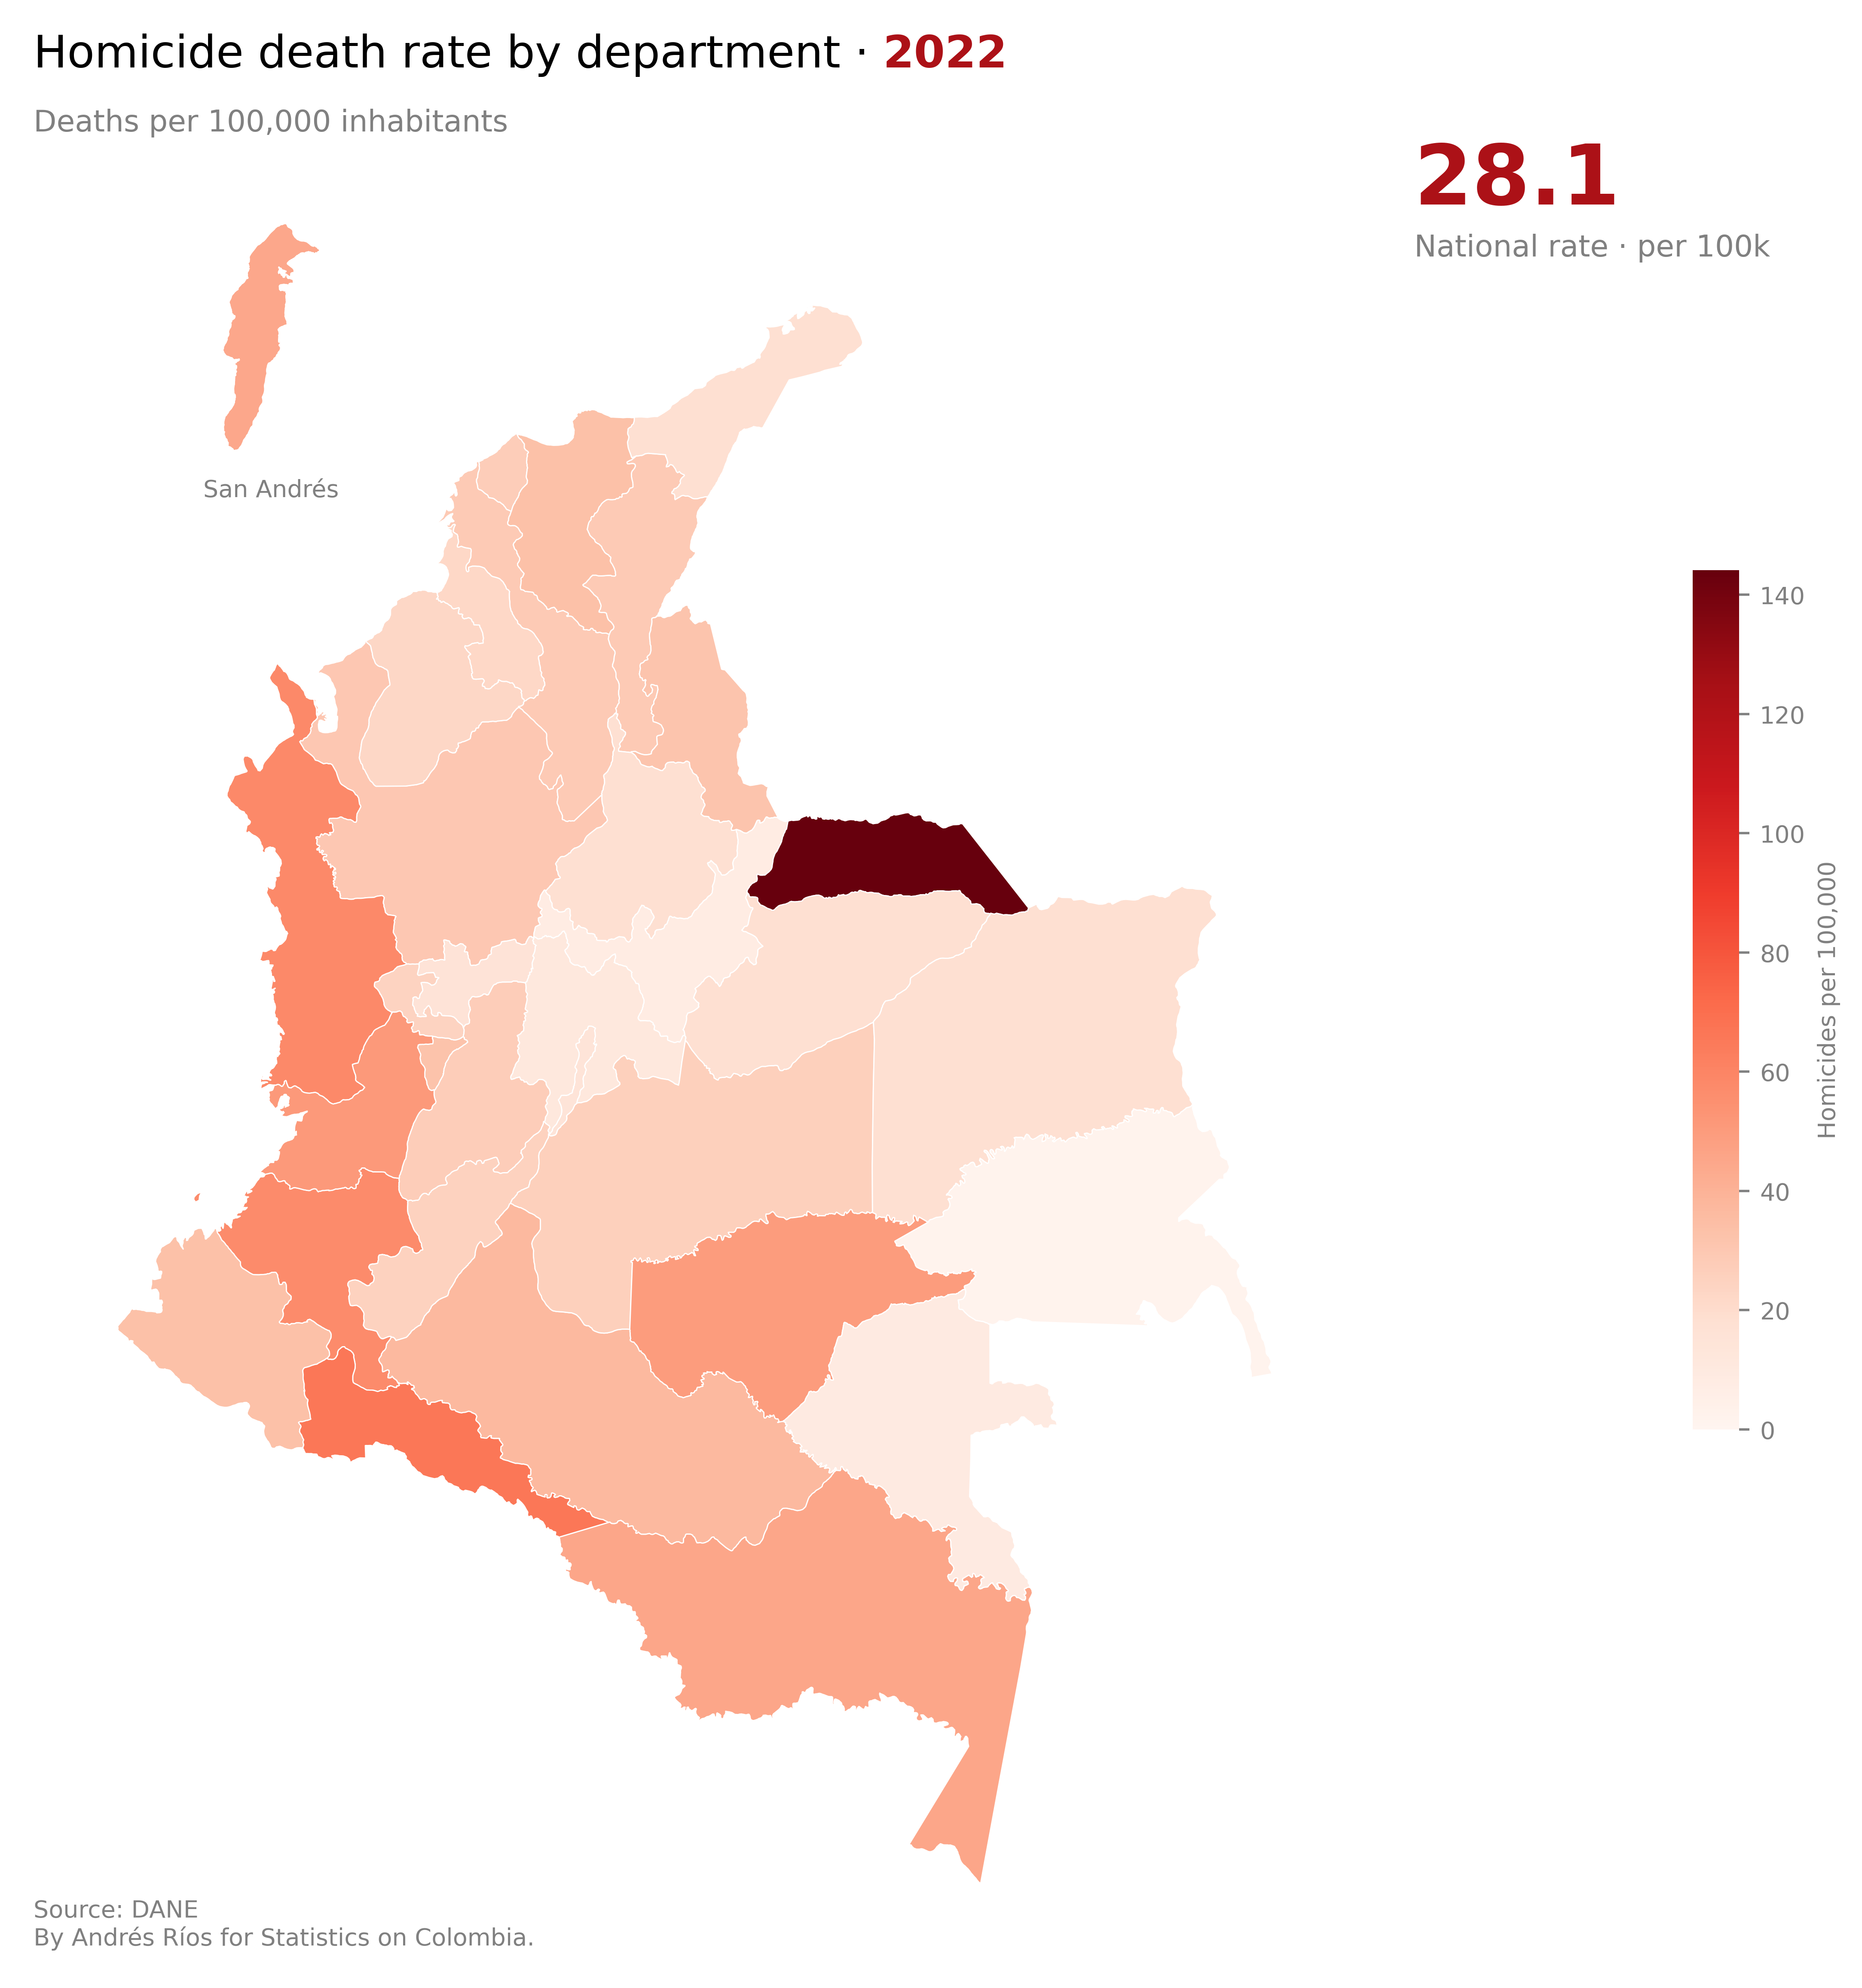

In [50]:
plot_rate_map(rate_2022, nat_2022, 2022)

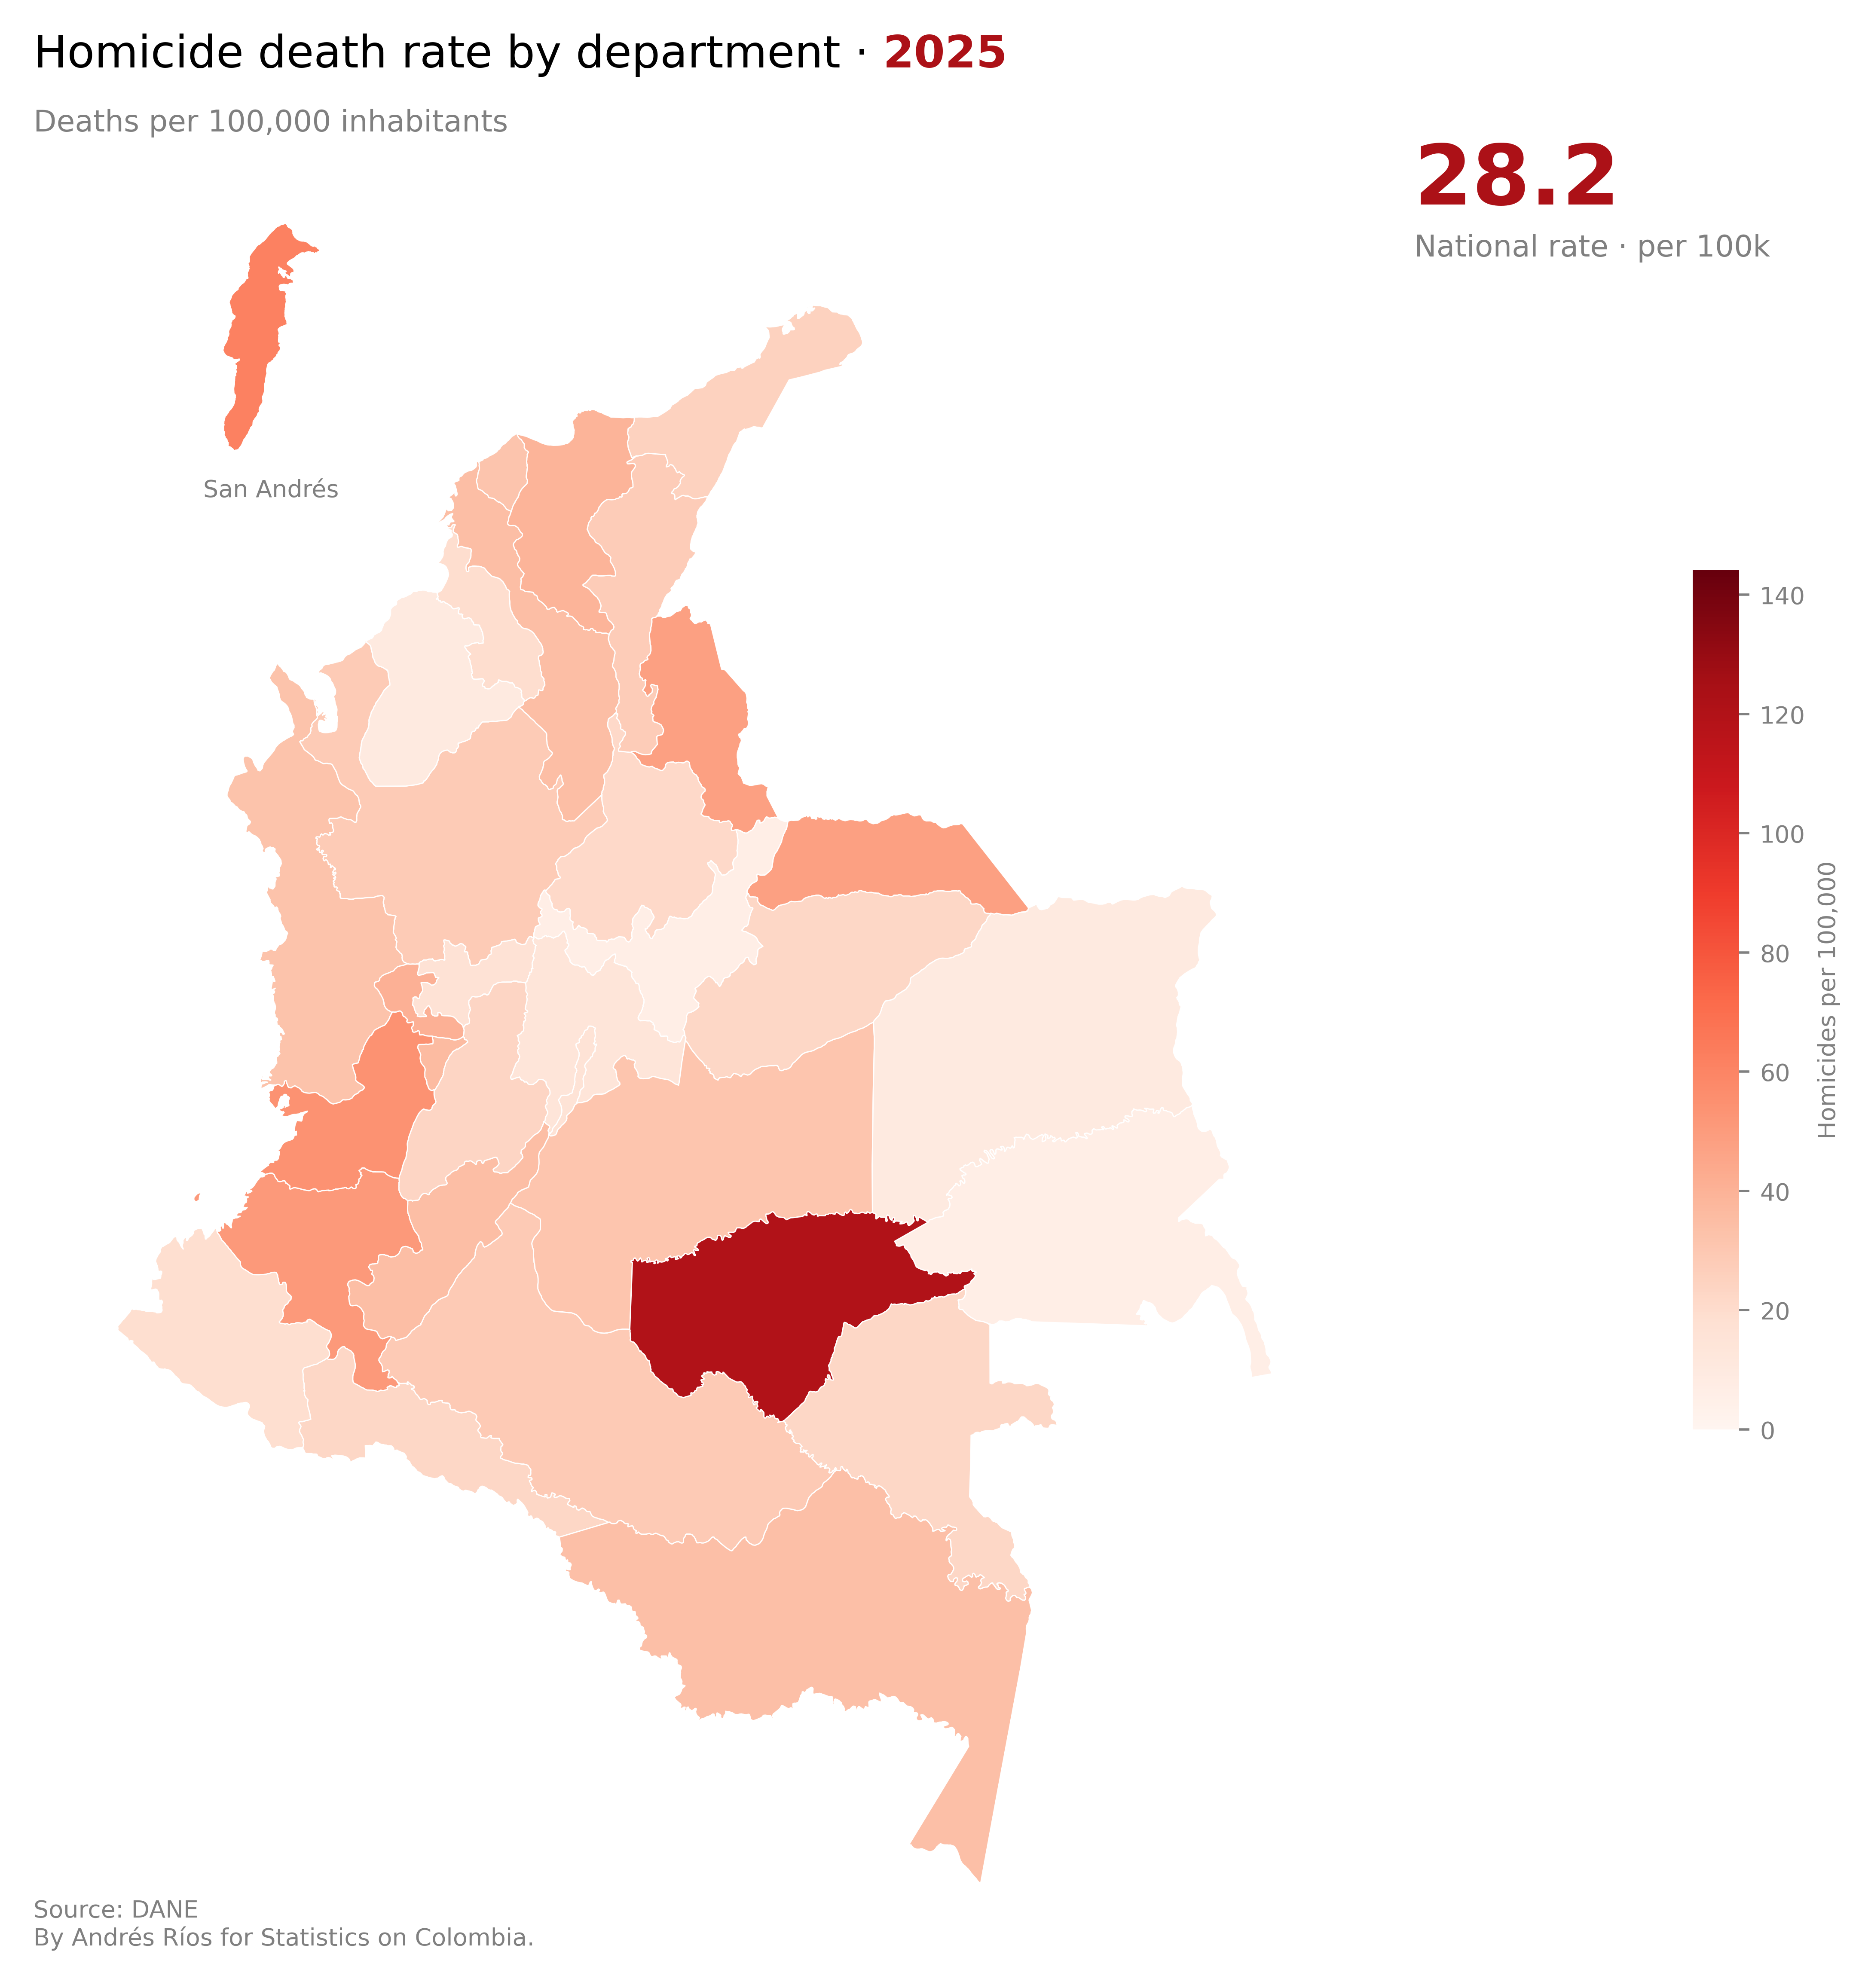

In [51]:
plot_rate_map(rate_2025, nat_2025, 2025)